In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import rosen, rosen_der

In [13]:
def evaluate_sigma(s, func, grad_func, x, d, delta, beta, dir_der):
    """
    Finds which region sigma is in: I1,I2, I3
    """
    # compute next values
    x_next = x + s * d
    f_next = func(x_next)
    grad_next = np.array(grad_func(x_next), dtype=float)
    
    # check both conditions
    armijo = f_next <= func(x) + delta * s * dir_der
    curvature = np.dot(grad_next, d) >= beta * dir_der
    
    if armijo and curvature:
        return "I2"
    elif armijo and not curvature:
        return "I1"
    else:
        return "I3"


def powell_line_search(func, grad_func, x, d, delta, beta, sigma_0, n_powell):
    # initialise variables
    grad_x = np.array(grad_func(x), dtype=float)
    dir_der = np.dot(grad_x, d)
    
    # evaluate if sigma_0 in I1,I2 or I3
    initial_region = evaluate_sigma(sigma_0, func, grad_func, x, d, delta, beta, dir_der)
    
    if initial_region == "I2":
        # desired region, we can stop
        return sigma_0
        
    elif initial_region == "I1":
        a = sigma_0 
        l = 1
        # finding l minimal such that G1(b0)< delta
        while True:
            b_candidate = (2**l) * sigma_0
            if evaluate_sigma(b_candidate, func, grad_func, x, d, delta, beta, dir_der) == "I3":
                b = b_candidate
                break
            l += 1
    else: 
        # We are in I3, set b0 = sigma_0 and find l minimal such that a0 in I1
        b = sigma_0
        l = 1
        while True:
            a_candidate = (2**(-l)) * sigma_0
            if evaluate_sigma(a_candidate, func, grad_func, x, d, delta, beta, dir_der) == "I1":
                a = a_candidate
                break
            l += 1

    # step 3: sigma_j = 1/2 * (a_j+b_j)
    for _ in range(n_powell):
        sigma_j = 0.5 * (a + b)
        region = evaluate_sigma(sigma_j, func, grad_func, x, d, delta, beta, dir_der)
        
        if region == "I2":
            return sigma_j
        elif region == "I1":
            a = sigma_j
        elif region == "I3":
            b = sigma_j
            
    return sigma_j

In [14]:
x_k = np.array([-1.2, 1.0])
n_max = 1000
n_powell = 100
delta = 0.1
sigma_0 = 1e-3
beta = 0.9
tol = 1e-5

path_rosenbrock = [x_k.copy()]

for k in range(n_max):
    grad = np.array(rosen_der(x_k), dtype=float)
    if np.linalg.norm(grad) < tol: # check for convergency
        print(f"{k}")
        break
        
    d = -grad  
    
    # calculate sigma using powell
    sigma = powell_line_search(
        rosen, rosen_der, x_k, d, 
        delta, beta, sigma_0, n_powell
    )
    
    # calculate x_k+1
    x_k += sigma * d
    path_rosenbrock.append(x_k.copy())
else:
    print("max iter")

path_rosenbrock = np.array(path_rosenbrock)

415


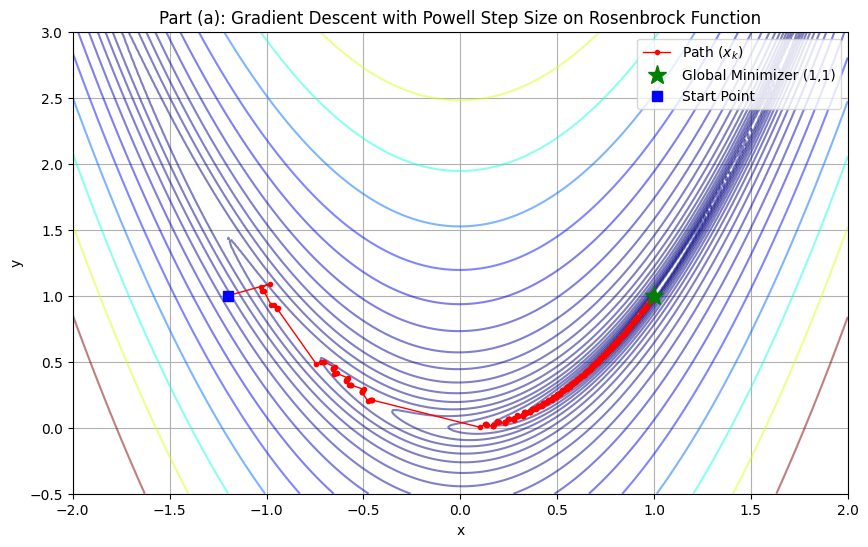

In [ ]:
plt.figure(figsize=(10, 6))
x_grid = np.linspace(-2.0, 2.0, 250)
y_grid = np.linspace(-0.5, 3.0, 250)
X, Y = np.meshgrid(x_grid, y_grid)

Z = np.zeros_like(X)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z[i, j] = rosen(np.array([X[i, j], Y[i, j]]))

plt.contour(X, Y, Z, levels=np.logspace(-1, 3, 20), cmap='jet', alpha=0.5)
plt.plot(path_rosenbrock[:, 0], path_rosenbrock[:, 1], 'ro-', markersize=3, linewidth=1, label='Path ($x_k$)')
plt.plot(1.0, 1.0, 'g*', markersize=14, label='Global Min (1,1)')
plt.plot(path_rosenbrock[0, 0], path_rosenbrock[0, 1], 'bs', markersize=7, label='Start Point')

plt.title("Gradient Descent with Powell Step Size on Rosenbrock Function")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

Part B

In [20]:
def q_f(x):
    return 40.0 * x[0]**2 + x[1]**2 + 10.0 * x[0] * x[1] - 20.0 * x[0] - 4.0 * x[1]

def q_grad(x):
    df_dx = 80.0 * x[0] + 10.0 * x[1] - 20.0
    df_dy = 10.0 * x[0] + 2.0 * x[1] - 4.0
    return np.array([df_dx, df_dy])

In [32]:
x_quad = np.array([5.0, 5.0]) 
max_iter = 1000
tol = 1e-6

path_quadratic = [x_quad.copy()]

for k in range(max_iter):
    grad = q_grad(x_quad)
    normgrad = np.linalg.norm(grad)
    
    if normgrad < tol:
        print(f"{k} iterations")
        break
        
    d = -grad
    
    # exact step size formula
    num = d[0]**2 + d[1]**2
    denom = 80.0 * d[0]**2 + 2.0 * d[1]**2 + 20.0 * d[0] * d[1]
    sigma = num / denom
    
    x_quad = x_quad + sigma * d
    path_quadratic.append(x_quad.copy())

path_quadratic = np.array(path_quadratic)

7 iterations


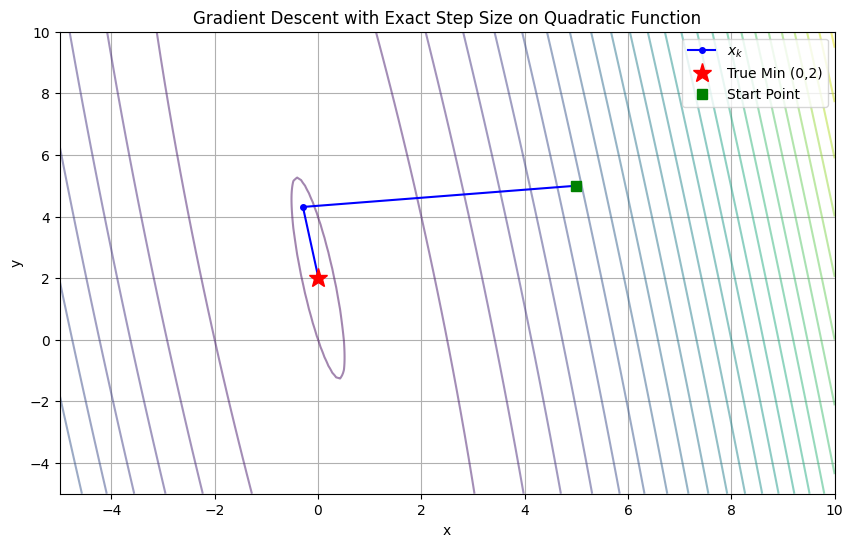

In [34]:
plt.figure(figsize=(10, 6))
x_grid_q = np.linspace(-5.0, 10.0, 200)
y_grid_q = np.linspace(-5.0, 10.0, 200)
X_q, Y_q = np.meshgrid(x_grid_q, y_grid_q)
Z_q = 40.0 * X_q**2 + Y_q**2 + 10.0 * X_q * Y_q - 20.0 * X_q - 4.0 * Y_q

true_minimizer = np.array([0.0, 2.0])

plt.contour(X_q, Y_q, Z_q, levels=30, cmap='viridis', alpha=0.5)
plt.plot(path_quadratic[:, 0], path_quadratic[:, 1], 'bo-', markersize=4, linewidth=1.5, label='$x_k$')
plt.plot(true_minimizer[0], true_minimizer[1], 'r*', markersize=14, label='True Min (0,2)')
plt.plot(path_quadratic[0, 0], path_quadratic[0, 1], 'gs', markersize=7, label='Start Point')

plt.title("Gradient Descent with Exact Step Size on Quadratic Function")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()